<a href="https://colab.research.google.com/github/Walidcanesse/CNN/blob/main/CNN_BREASTCANCER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KAGGLE DATA


In [18]:
import os
from google.colab import files

# 1. Upload kaggle.json
print("Upload kaggle.json here:")
files.upload()

# 2. Create the hidden .kaggle folder for authentication
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# 3. Change permissions (security required by Kaggle)
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle installation complete!")

Upload kaggle.json here:


Saving kaggle.json to kaggle (5).json
Kaggle installation complete!


In [19]:
# 1. Download the dataset (direct API command)
print("Download in progress...")
!kaggle datasets download -d paultimothymooney/breast-histopathology-images

# 2. Decompression
print("Decompressing files (this may take 1 to 2 minutes)...")
# Unzip into a specific 'data' folder to avoid cluttering the root directory
!unzip -q breast-histopathology-images.zip -d data

print("Done! Data is in the 'data' folder")

Download in progress...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images
License(s): CC0-1.0
breast-histopathology-images.zip: Skipping, found more recently modified local copy (use --force to force download)
Decompressing files (this may take 1 to 2 minutes)...
replace data/10253/0/10253_idx5_x1001_y1001_class0.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: Done! Data is in the 'data' folder


In [20]:
# Display the first 20 files/folders up to 3 levels deep
!find data -maxdepth 3 | head -n 20

data
data/12886
data/12886/1
data/12886/1/12886_idx5_x601_y251_class1.png
data/12886/1/12886_idx5_x201_y751_class1.png
data/12886/1/12886_idx5_x251_y801_class1.png
data/12886/1/12886_idx5_x951_y701_class1.png
data/12886/1/12886_idx5_x1001_y651_class1.png
data/12886/1/12886_idx5_x951_y301_class1.png
data/12886/1/12886_idx5_x451_y951_class1.png
data/12886/1/12886_idx5_x901_y651_class1.png
data/12886/1/12886_idx5_x651_y551_class1.png
data/12886/1/12886_idx5_x901_y201_class1.png
data/12886/1/12886_idx5_x351_y801_class1.png
data/12886/1/12886_idx5_x751_y601_class1.png
data/12886/1/12886_idx5_x801_y401_class1.png
data/12886/1/12886_idx5_x1101_y351_class1.png
data/12886/1/12886_idx5_x501_y851_class1.png
data/12886/1/12886_idx5_x301_y551_class1.png
data/12886/1/12886_idx5_x551_y501_class1.png


## 1. Dataset Overview & Structure

We are using the **Breast Histopathology Images** dataset. It contains small image patches extracted from microscopic scans of breast tissue.

### A. Directory Structure
The dataset is organized hierarchically by **Patient ID** and then by **Class**:

* **Root:** `data/`
* **Level 1:** `Patient_ID` (e.g., `16532/`, `10253/`...) represents a specific patient.
* **Level 2:** `Class Label` (0 or 1).
    * `0`: **Benign** (Healthy tissue).
    * `1`: **Malignant** (Cancerous tissue - Invasive Ductal Carcinoma).

### B. Filename Convention
Each file follows a specific naming pattern:
> `16532_idx5_x1601_y1101_class0.png`

* `16532`: Patient ID.
* `x1601_y1101`: Coordinates of the patch on the original slide.
* `class0`: The ground truth label (0 or 1).


### 💡 Important Note: Where do these images come from?

You might notice that a single patient ID folder contains hundreds of images.
* **Context:** The original data comes from **Whole Slide Images (WSI)** (gigantic scans of breast tissue).
* **Patching:** Because these scans are too large, they are cut into small **50x50 pixel patches**.
* **Result:**
    * Each file represents a tiny region of the patient's tissue.
    * A single patient contributes hundreds of patches to the dataset.
    * Our goal is to classify each *patch* individually.

# DATA CLEANING

## INTO DATAFRAME

In [21]:
import pandas as pd
from glob import glob
import os

# 1. Retrieve all image paths using glob
# We search recursively in 'data'
print("Scanning files... This may take a moment.")
image_paths = glob('data/**/*.png', recursive=True)

print(f"Total number of images found: {len(image_paths)}")

# 2. Extract path information
# Observed image structure: data/16532/0/filename.png
data = []

for path in image_paths:
    # We split the path to extract folders
    # Path example: 'data/16532/0/img.png'
    # normpath ensures separator consistency (/ or \)
    parts = os.path.normpath(path).split(os.sep)

    # Based on the dataset structure:
    # parts[-1] = filename
    # parts[-2] = class_id ('0' or '1')
    # parts[-3] = patient_id ('16532')

    label = parts[-2]
    patient_id = parts[-3]

    # We only add valid images (security check)
    if label in ['0', '1']:
        data.append({
            'path': path,
            'label': int(label),
            'patient_id': patient_id
        })

# 3. Create the DataFrame
df = pd.DataFrame(data)

# 4. Display statistics
print("-" * 30)
print(f"DataFrame shape: {df.shape}")
print("Class distribution:")
print(df['label'].value_counts())
print("-" * 30)
df.head()

Scanning files... This may take a moment.
Total number of images found: 555048
------------------------------
DataFrame shape: (555048, 3)
Class distribution:
label
0    397476
1    157572
Name: count, dtype: int64
------------------------------


,path,label,patient_id
0,data/12886/1/12886_idx5_x601_y251_class1.png,1,12886
1,data/12886/1/12886_idx5_x201_y751_class1.png,1,12886
2,data/12886/1/12886_idx5_x251_y801_class1.png,1,12886
3,data/12886/1/12886_idx5_x951_y701_class1.png,1,12886
4,data/12886/1/12886_idx5_x1001_y651_class1.png,1,12886


## Data Preparation: Balancing & Splitting

### A. Addressing Class Imbalance (Undersampling)
**The Observation:**
Our initial exploration revealed a massive imbalance: ~397,000 healthy images (Class 0) vs. ~157,000 cancerous images (Class 1).

**The Problem:**
If we train on this raw data, the model can become "lazy." It could achieve ~72% accuracy simply by guessing "Healthy" for every image, without ever learning to detect cancer.

**The Solution:**
We performed **Undersampling**. We randomly selected **50,000 images** from each class to create a perfectly balanced dataset (100,000 images total).
* *Benefit 1:* Removes bias (50/50 ratio).
* *Benefit 2:* Reduces training time on Google Colab (processing 500k images would take too long).

### B. Creating the Train / Validation / Test Splits
To evaluate our model rigorously and prevent **Overfitting**, we split our balanced dataset into three distinct parts:

1.  **Training Set (80%):**
    * Used by the model to learn and update its weights.
2.  **Validation Set (10%):**
    * Used during training to monitor performance after each epoch.
    * *Goal:* Helps us tune hyperparameters and stop early if the model starts memorizing.
3.  **Test Set (10%):**
    * *Goal:* Used **only once** at the very end to measure the true performance of the model on completely unseen data.

In [22]:
from sklearn.model_selection import train_test_split

# --- STEP 1: BALANCING (UNDERSAMPLING) ---

# We separate the two classes
df_0 = df[df['label'] == 0]
df_1 = df[df['label'] == 1]

print(f"Class 0 (Healthy): {len(df_0)}")
print(f"Class 1 (Diseased): {len(df_1)}")

# MODIFICATION HERE: We switch to 10 000 images per class to speed things up
SAMPLE_SIZE = 10000

# We take 10k random samples from healthy
df_0_balanced = df_0.sample(SAMPLE_SIZE, random_state=42)
# We take 10k random samples from diseased
df_1_balanced = df_1.sample(SAMPLE_SIZE, random_state=42)

# We reassemble the pieces
df_balanced = pd.concat([df_0_balanced, df_1_balanced])

# We shuffle everything so we don't have all 0s then all 1s
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("-" * 30)
print(f"New reduced and balanced Dataset: {len(df_balanced)} images")
print(df_balanced['label'].value_counts())


# --- STEP 2: SPLITTING (TRAIN / VAL / TEST) ---

# We want: Train (80%), Val (10%), Test (10%)

# 1. First, we split into: Train (80%) and Rest (20%)
train_df, temp_df = train_test_split(df_balanced, test_size=0.2, stratify=df_balanced['label'], random_state=42)

# 2. We split the Rest into two: Val (50% of rest) and Test (50% of rest)
# 50% of 20% -> that makes 10% of the total
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print("-" * 30)
print(f"Training set size: {len(train_df)}")
print(f"Validation set size:  {len(val_df)}")
print(f"Test set size:        {len(test_df)}")

Class 0 (Healthy): 397476
Class 1 (Diseased): 157572
------------------------------
New reduced and balanced Dataset: 20000 images
label
1    10000
0    10000
Name: count, dtype: int64
------------------------------
Training set size: 16000
Validation set size:  2000
Test set size:        2000


## EXAMPLE OF IMAGES

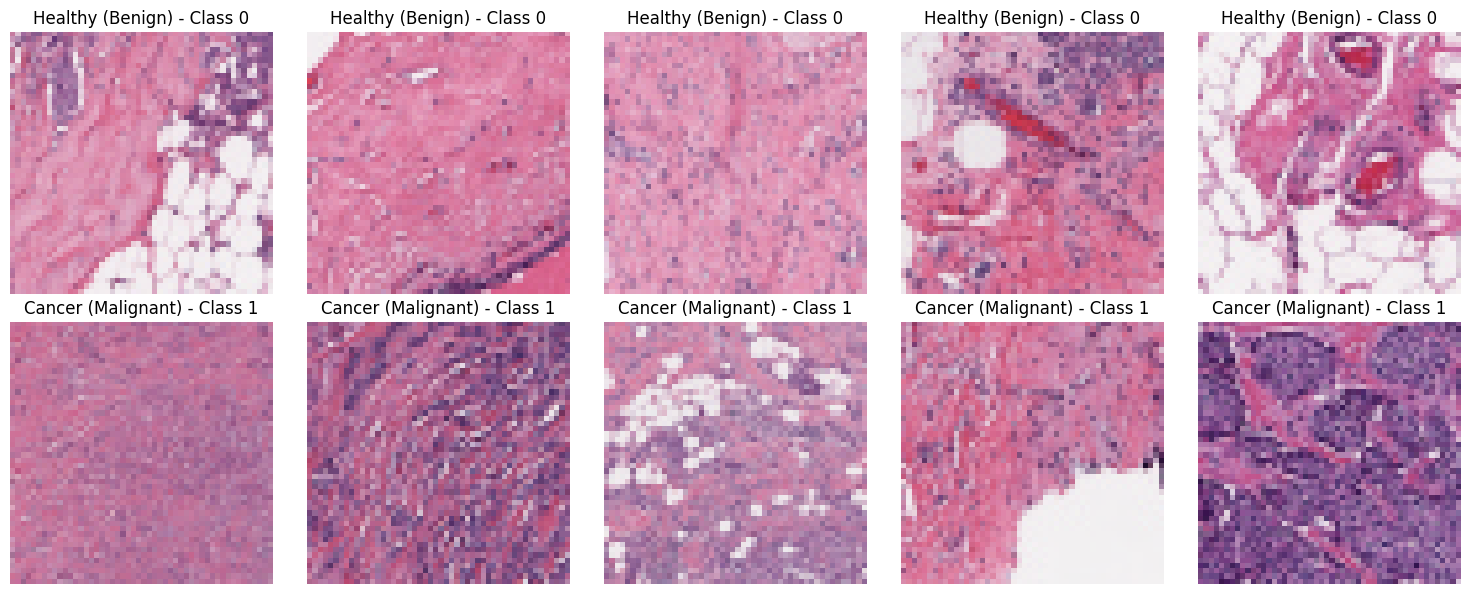

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# We configure the figure (2 rows, 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# 1. We take 5 random images from HEALTHY (Class 0)
healthy_samples = train_df[train_df['label'] == 0].sample(5, random_state=42)

# 2. We take 5 random images from DISEASED (Class 1)
cancer_samples = train_df[train_df['label'] == 1].sample(5, random_state=42)

# --- Display Row 1: HEALTHY ---
for i, (index, row) in enumerate(healthy_samples.iterrows()):
    img = mpimg.imread(row['path'])
    ax = axes[0, i]
    ax.imshow(img)
    ax.set_title("Healthy (Benign) - Class 0")
    ax.axis('off') # Remove ugly axes

# --- Display Row 2: DISEASED ---
for i, (index, row) in enumerate(cancer_samples.iterrows()):
    img = mpimg.imread(row['path'])
    ax = axes[1, i]
    ax.imshow(img)
    ax.set_title("Cancer (Malignant) - Class 1")
    ax.axis('off')

plt.tight_layout()
plt.show()

# CNN

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import time
import matplotlib.pyplot as plt

# Base Configuration
BATCH_SIZE = 128
IMG_SIZE = 50
NUM_WORKERS = 2 #speed

In [25]:
# 1. Transformation Pipelines (Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5), # Horizontal flip
    transforms.RandomVerticalFlip(p=0.5),   # Vertical flip
    transforms.RandomRotation(20),          # Rotation +/- 20°
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# 2. The Custom Dataset Class
class BreastCancerDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['path']
        label = row['label']
        # Open image
        image = Image.open(image_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# 3. Create Loaders (DataLoaders)
train_dataset = BreastCancerDataset(train_df, transform=train_transforms)
val_dataset   = BreastCancerDataset(val_df,   transform=val_transforms)
test_dataset  = BreastCancerDataset(test_df,  transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS, # Parallelism
    pin_memory=True          # Fast transfer to GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
print("✅ DataLoaders ready!")

✅ DataLoaders ready!


In [26]:
import torch
import torch.nn as nn

# Utility function to create a block (Conv -> BN -> ReLU -> Conv -> BN -> ReLU -> MaxPool)
def conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

class BreastCancerCNN(nn.Module):
    def __init__(self):
        super(BreastCancerCNN, self).__init__()

        # Convolution Part (Feature Extraction)
        # Input assumed: (N, 3, 50, 50)
        self.block1 = conv_block(3, 32)    # (N, 3, 50, 50)  -> (N, 32, 25, 25)
        self.block2 = conv_block(32, 64)   # (N, 32, 25, 25) -> (N, 64, 12, 12)
        self.block3 = conv_block(64, 128)  # (N, 64, 12, 12) -> (N, 128, 6, 6)

        # Flatten
        self.flatten = nn.Flatten()

        # Classification Part (MLP)
        #  4608 -> 512 -> 512 -> 1  (two hidden layers, with dropout)
        self.classifier = nn.Sequential(
            nn.Linear(128 * 6 * 6, 512),  # 4608 -> 512
            nn.ReLU(),
            nn.Dropout(p=0.5),            # Anti-overfitting

            nn.Linear(512, 512),          # second hidden layer: 512 -> 512
            nn.ReLU(),
            nn.Dropout(p=0.5),

            nn.Linear(512, 1)             # final logit for binary classification
        )

    def forward(self, x):
        # Convolutional feature extractor
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        logits = self.classifier(x)
        return logits

print("✅  BreastCancerCNN architecture defined!")


✅  BreastCancerCNN architecture defined!



1. **Input**: `(N, 3, 50, 50)`
2. **After Block 1**: `(N, 32, 25, 25)`
3. **After Block 2**: `(N, 64, 12, 12)`
4. **After Block 3**: `(N, 128, 6, 6)`
5. **After Flatten**: `(N, 4608)`
6. **MLP with 2 hidden layers 512 and 512**

This describes the **full CNN pipeline** and the **output dimension at each sub-step**.


In [27]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    model = model.to(device)
    print(f"🚀 Starting training on {device} for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        start_time = time.time()

        # --- PHASE 1: TRAINING ---
        model.train()
        running_loss, correct_preds, total_preds = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.unsqueeze(1).float()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            predicted = (outputs > 0).float()
            correct_preds += (predicted == labels).sum().item()
            total_preds += labels.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct_preds / total_preds

        # --- PHASE 2: VALIDATION ---
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                labels = labels.unsqueeze(1).float()

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                predicted = (outputs > 0).float()
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = correct_val / total_val

        # --- STORE SCORES ---
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"Time: {time.time() - start_time:.0f}s")

    print("🏁 Training complete!")
    return history

In [28]:
# 1. GPU Detection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute device: {device}")

# 2. Model Creation
model = BreastCancerCNN().to(device)

# 3. Define Loss and Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Compute device: cuda


In [30]:
# We run for 10 epochs
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=20
)

🚀 Starting training on cuda for 20 epochs...
Epoch 1/20 | Train Loss: 0.4237 Acc: 0.8186 | Val Loss: 0.3975 Acc: 0.8310 | Time: 16s
Epoch 2/20 | Train Loss: 0.4042 Acc: 0.8301 | Val Loss: 0.3930 Acc: 0.8290 | Time: 12s
Epoch 3/20 | Train Loss: 0.3930 Acc: 0.8363 | Val Loss: 0.3834 Acc: 0.8210 | Time: 12s
Epoch 4/20 | Train Loss: 0.3819 Acc: 0.8391 | Val Loss: 0.3626 Acc: 0.8420 | Time: 12s
Epoch 5/20 | Train Loss: 0.3741 Acc: 0.8429 | Val Loss: 0.3654 Acc: 0.8435 | Time: 12s
Epoch 6/20 | Train Loss: 0.3657 Acc: 0.8483 | Val Loss: 0.3794 Acc: 0.8340 | Time: 11s
Epoch 7/20 | Train Loss: 0.3617 Acc: 0.8478 | Val Loss: 0.4191 Acc: 0.8240 | Time: 11s
Epoch 8/20 | Train Loss: 0.3551 Acc: 0.8514 | Val Loss: 0.3609 Acc: 0.8475 | Time: 12s
Epoch 9/20 | Train Loss: 0.3475 Acc: 0.8566 | Val Loss: 0.3469 Acc: 0.8475 | Time: 12s
Epoch 10/20 | Train Loss: 0.3482 Acc: 0.8552 | Val Loss: 0.3544 Acc: 0.8490 | Time: 12s
Epoch 11/20 | Train Loss: 0.3453 Acc: 0.8548 | Val Loss: 0.3447 Acc: 0.8495 | Time: 

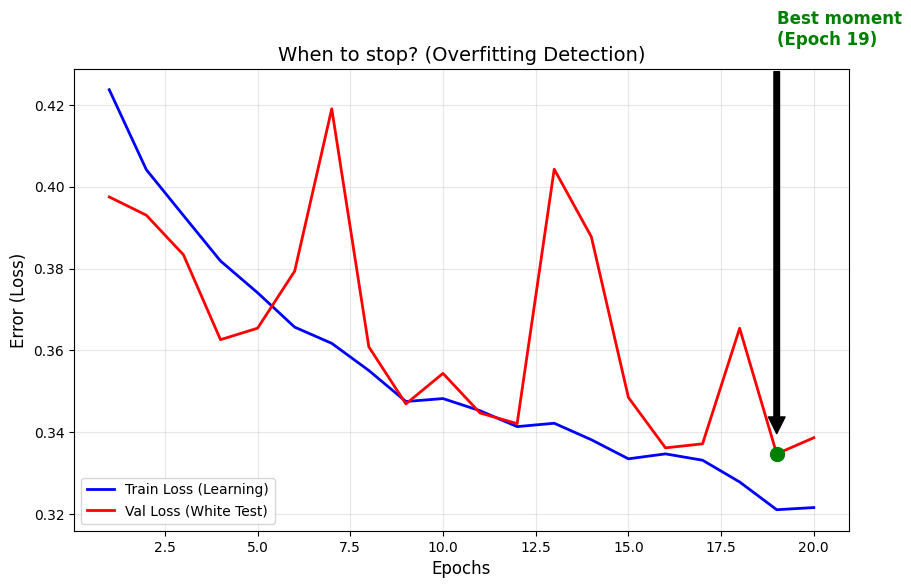

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loss_curve(history):
    train_loss = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(train_loss) + 1)

    # Find the best point (Minimum Validation Loss)
    best_epoch = np.argmin(val_loss) + 1
    best_val_loss = val_loss[best_epoch - 1]

    plt.figure(figsize=(10, 6))

    # 1. Plot the curves
    plt.plot(epochs, train_loss, 'b-', label='Train Loss (Learning)', linewidth=2)
    plt.plot(epochs, val_loss, 'r-', label='Val Loss (White Test)', linewidth=2)

    # 2. Mark the ideal stopping point
    plt.scatter(best_epoch, best_val_loss, c='green', s=100, zorder=5)
    plt.annotate(f'Best moment\n(Epoch {best_epoch})',
                 xy=(best_epoch, best_val_loss),
                 xytext=(best_epoch, best_val_loss + 0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=12, color='green', fontweight='bold')

    plt.title('When to stop? (Overfitting Detection)', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Error (Loss)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Display the graph
plot_loss_curve(history)

🏥 Test Set Diagnostics in progress...


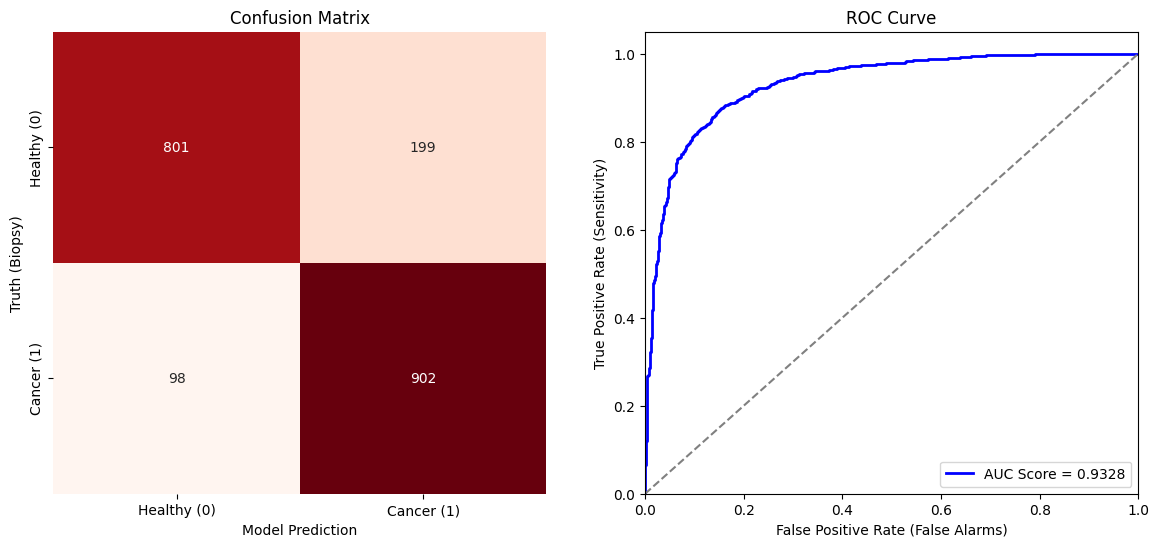

🎯 ACCURACY:         0.8515
🏆 FINAL AUC SCORE: 0.9328 / 1.0
CRITICAL DETAILS:
✅ Cancers correctly detected (True Positives): 902
✅ Healthy correctly ignored (True Negatives):   801
⚠️ False Alarms (False Positives):              199
🚨 MISSED CANCERS (False Negatives - DANGER):       98


In [32]:
from sklearn.metrics import *
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

def evaluate_model_auc(model, test_loader):
    model.eval() # Disable training mode (no dropout)

    y_true = []
    y_probs = [] # Store probabilities (not just 0 or 1) for AUC

    print("🏥 Test Set Diagnostics in progress...")

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            # 1. Forward pass (Raw logits)
            logits = model(images)

            # 2. Transformation to Probabilities (Sigmoid) -> between 0 and 1
            probs = torch.sigmoid(logits)

            # Store on CPU for sklearn
            y_true.extend(labels.numpy())
            y_probs.extend(probs.cpu().numpy())

    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    # For the confusion matrix, we cut at 0.5
    y_pred = (y_probs > 0.5).astype(int)

     # Accuracy (global correctness rate)
    accuracy = accuracy_score(y_true, y_pred)


    # --- 1. CONFUSION MATRIX (Most important) ---
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    plt.figure(figsize=(14, 6))

    # Plot A: The Matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
                xticklabels=['Healthy (0)', 'Cancer (1)'],
                yticklabels=['Healthy (0)', 'Cancer (1)'])
    plt.xlabel('Model Prediction')
    plt.ylabel('Truth (Biopsy)')
    plt.title('Confusion Matrix')

    # --- 2. ROC CURVE & AUC ---
    # Calculate the curve
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    # Calculate the Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)

    # Plot B: The Curve
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC Score = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Random line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (False Alarms)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")

    plt.show()

    # --- FINAL REPORT ---
    print(f"🎯 ACCURACY:         {accuracy:.4f}")
    print("="*40)
    print(f"🏆 FINAL AUC SCORE: {roc_auc:.4f} / 1.0")
    print("="*40)
    print("CRITICAL DETAILS:")
    print(f"✅ Cancers correctly detected (True Positives): {tp}")
    print(f"✅ Healthy correctly ignored (True Negatives):   {tn}")
    print(f"⚠️ False Alarms (False Positives):              {fp}")
    print(f"🚨 MISSED CANCERS (False Negatives - DANGER):       {fn}")
    print("="*40)

# Launch
evaluate_model_auc(model, test_loader)